<a href="https://colab.research.google.com/github/tdtai09423/weather-forecast-group-project/blob/main/data_workspace/notebooks/01_EDA/Stage1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

Input Data

In [9]:
for dirname, _, filenames in os.walk('/content/sample_data/weather-forecast-data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/sample_data/weather-forecast-data/tuassouth.csv
/content/sample_data/weather-forecast-data/angmokio.csv
/content/sample_data/weather-forecast-data/changi.csv


In [28]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow # Changed to integer division
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [46]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = getattr(df, 'dataframeName', 'unknown')

    # Only keep numerical columns
    df = df.select_dtypes(include=[np.number])

    # Drop columns with NaN values
    df = df.dropna(axis='columns')

    # Keep columns with more than 1 unique value
    df = df[[col for col in df if df[col].nunique() > 1]]

    if df.shape[1] < 2:
        print(f'No correlation plots shown for {filename}: The number of valid numerical columns ({df.shape[1]}) is less than 2')
        return

    corr = df.corr()

    # Fill NaNs in correlation matrix if they exist
    if corr.isnull().values.any():
        corr = corr.fillna(0)

    # Fix: Create figure separately to avoid the truth value ambiguity error in matshow/figure logic
    plt.figure(figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    ax = plt.gca()
    corrMat = ax.matshow(corr, cmap='coolwarm')

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

In [50]:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number])
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

DF1

In [11]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# angmokio.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df1 = pd.read_csv('/content/sample_data/weather-forecast-data/angmokio.csv', delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'angmokio.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 14 columns


In [12]:
df1.head(5)

,Unnamed: 0,Station,Year,Month,Day,Daily Rainfall Total (mm),Highest 30 min Rainfall (mm),Highest 60 min Rainfall (mm),Highest 120 min Rainfall (mm),Mean Temperature (°C),Maximum Temperature (°C),Minimum Temperature (°C),Mean Wind Speed (km/h),Max Wind Speed (km/h)
0,0,Ang Mo Kio,2014,1,1,0.0,0.0,0.0,0.0,26.3,28.7,24.5,7.2,29.9
1,1,Ang Mo Kio,2014,1,2,0.0,0.0,0.0,0.0,26.9,30.4,24.6,8.2,32.0
2,2,Ang Mo Kio,2014,1,3,8.8,8.6,8.8,8.8,26.5,30.1,24.8,7.1,29.5
3,3,Ang Mo Kio,2014,1,4,1.4,1.4,1.4,1.4,26.6,30.9,24.7,4.2,30.2
4,4,Ang Mo Kio,2014,1,5,7.2,1.6,3.2,5.2,24.5,25.5,23.3,5.2,24.1


In [45]:
display(df1.describe())

,Unnamed: 0,Year,Month,Day,Daily Rainfall Total (mm),Highest 30 min Rainfall (mm),Highest 60 min Rainfall (mm),Highest 120 min Rainfall (mm),Mean Temperature (°C),Maximum Temperature (°C),Minimum Temperature (°C),Mean Wind Speed (km/h),Max Wind Speed (km/h)
count,1000.000000,1000.000000,1000.000000,1000.000000,999.000000,999.000000,999.000000,999.000000,993.000000,993.000000,993.000000,996.000000,995.000000
mean,499.500000,2014.905000,6.100000,15.672000,5.501702,3.635035,4.424424,4.883083,28.045217,32.066062,25.290131,6.089458,30.762111
std,288.819436,0.791582,3.307407,8.780861,11.586634,7.480825,9.390592,10.448013,1.222957,1.636198,1.455919,1.690452,6.893925
min,0.000000,2014.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,24.500000,25.500000,20.300000,3.000000,13.700000
25%,249.750000,2014.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,27.200000,31.200000,24.200000,4.700000,26.300000
50%,499.500000,2015.000000,6.000000,16.000000,0.000000,0.000000,0.000000,0.000000,28.100000,32.300000,25.300000,5.800000,29.900000
75%,749.250000,2016.000000,9.000000,23.000000,5.000000,3.200000,3.600000,4.200000,29.000000,33.200000,26.300000,7.200000,34.600000
max,999.000000,2016.000000,12.000000,31.000000,88.600000,54.200000,67.800000,84.600000,31.100000,35.800000,28.600000,11.200000,73.800000


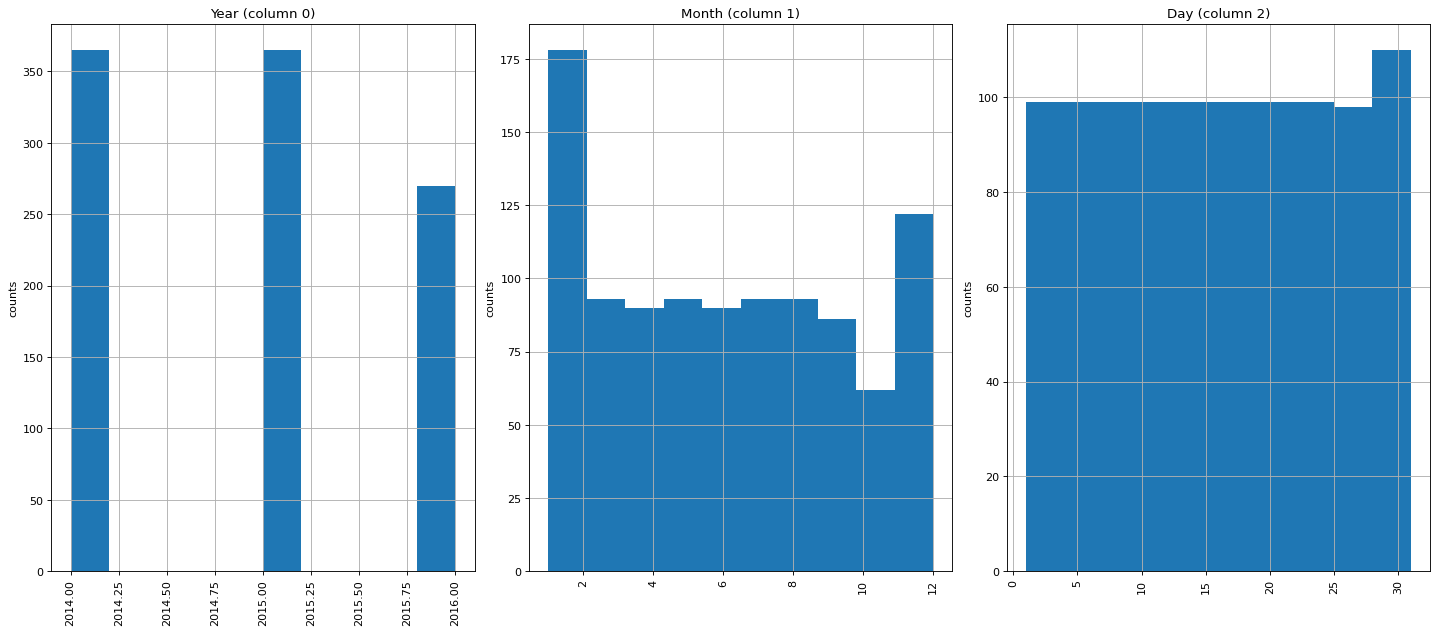

In [20]:
plotPerColumnDistribution(df1, 10, 5)

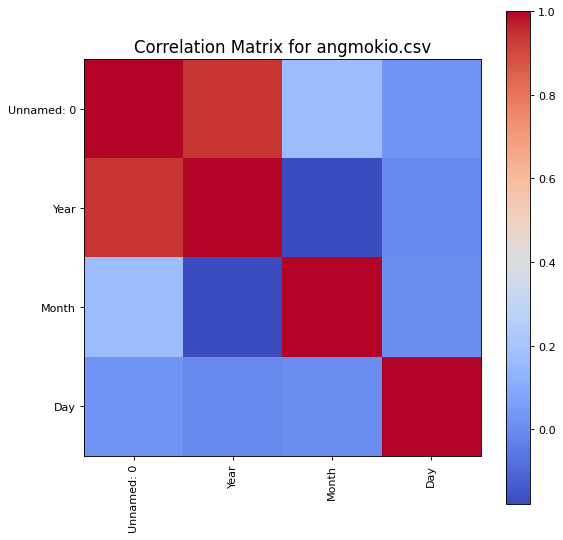

In [47]:
plotCorrelationMatrix(df1, 8)

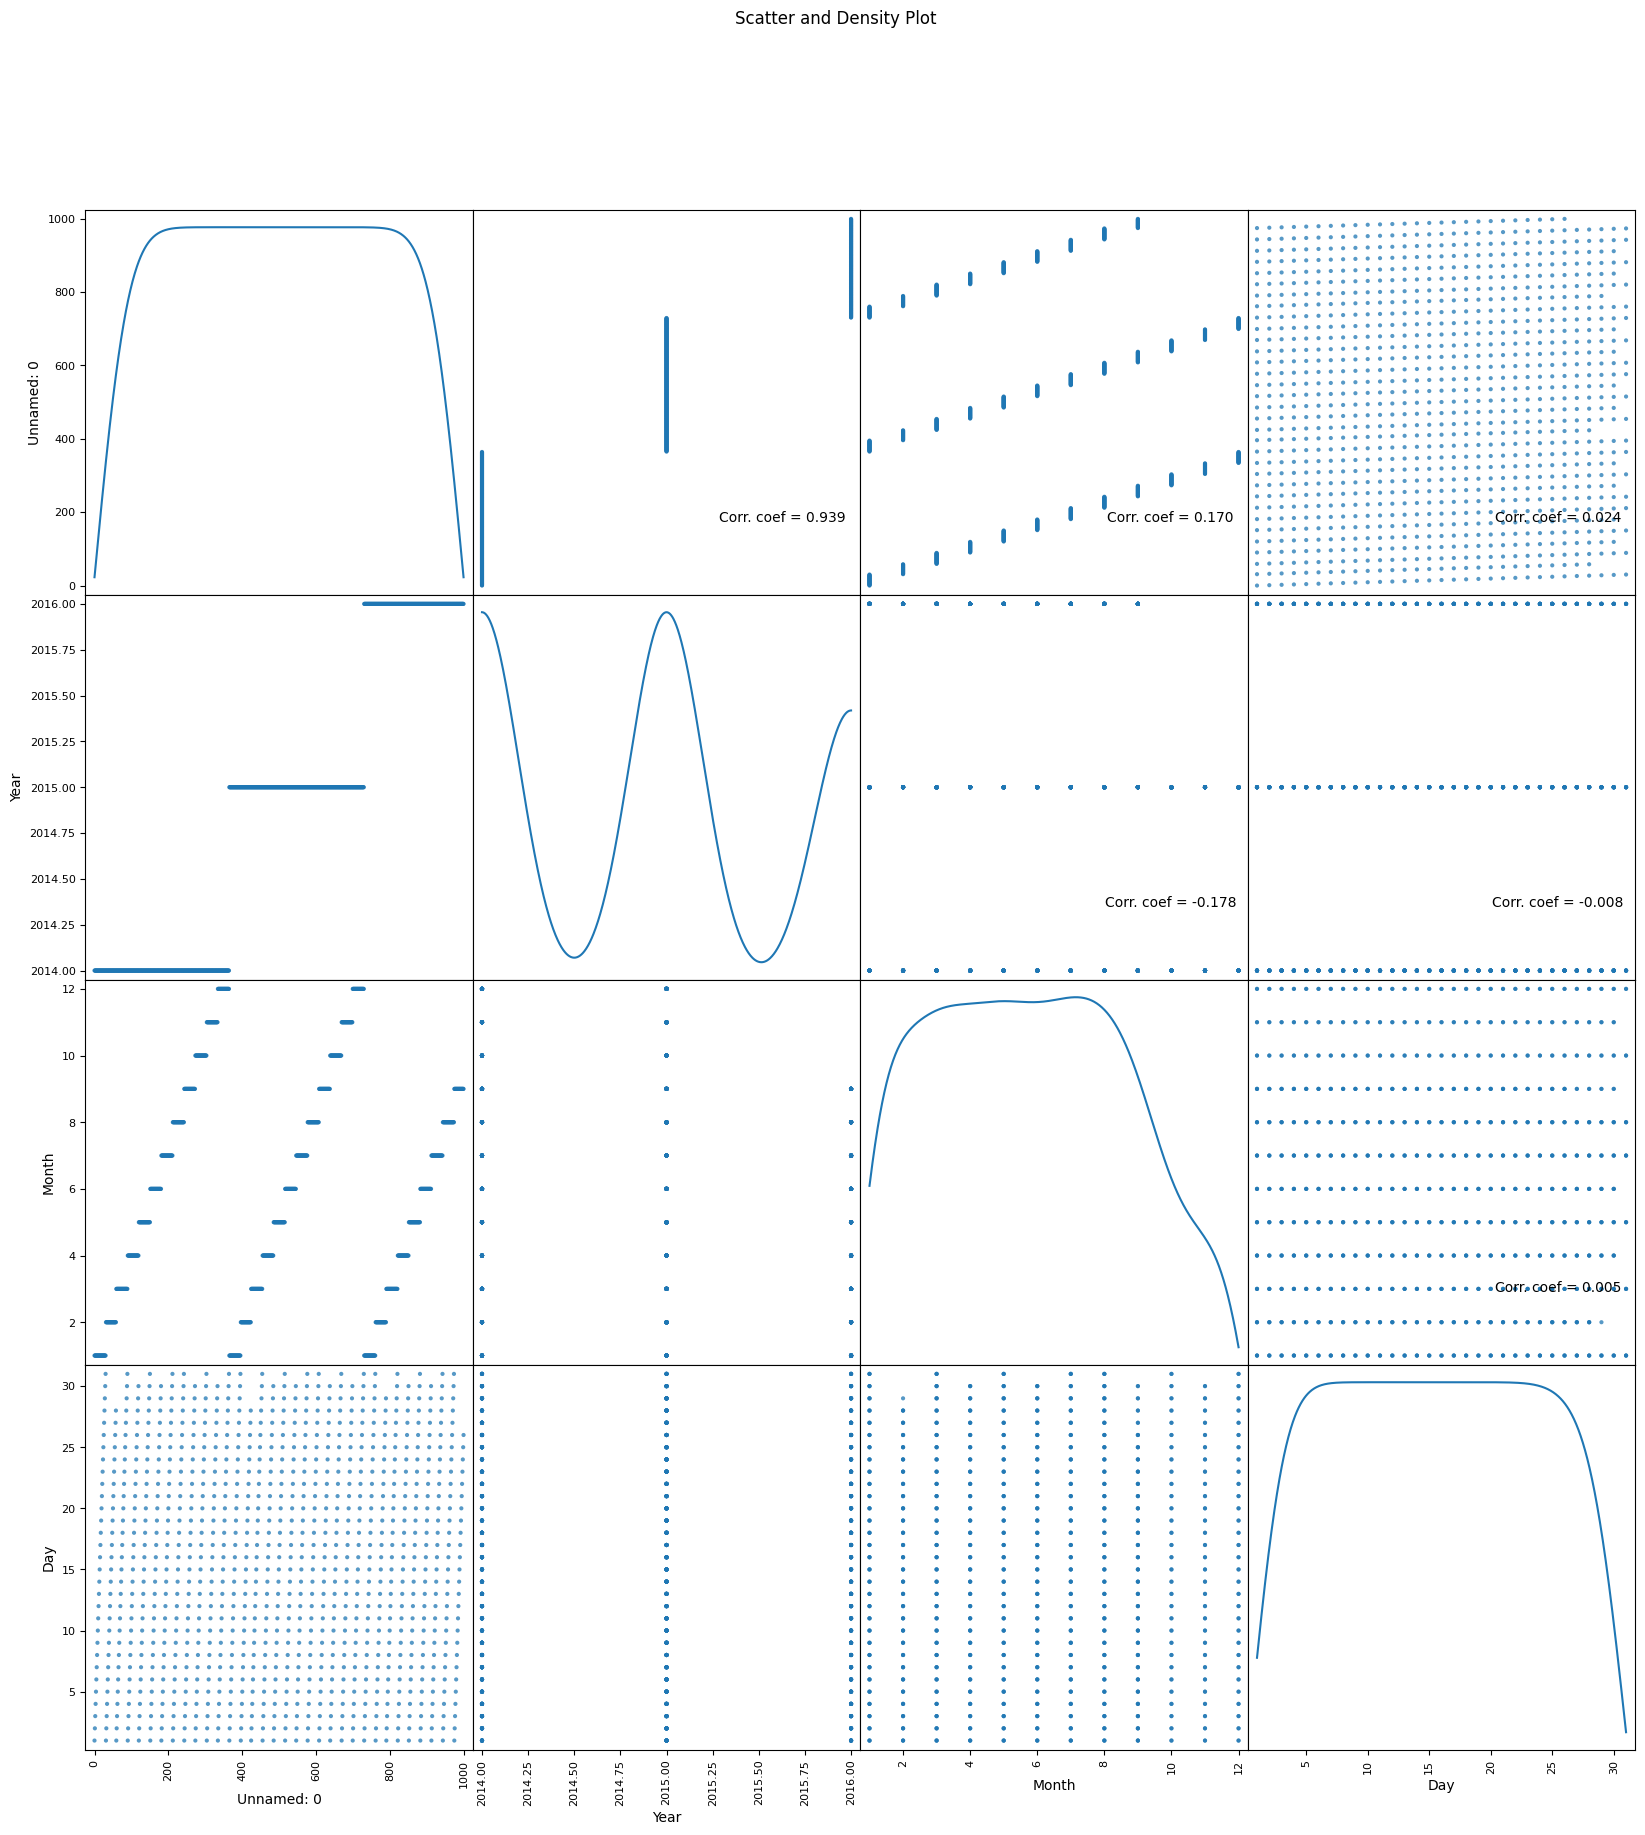

In [51]:
plotScatterMatrix(df1, 20, 10)

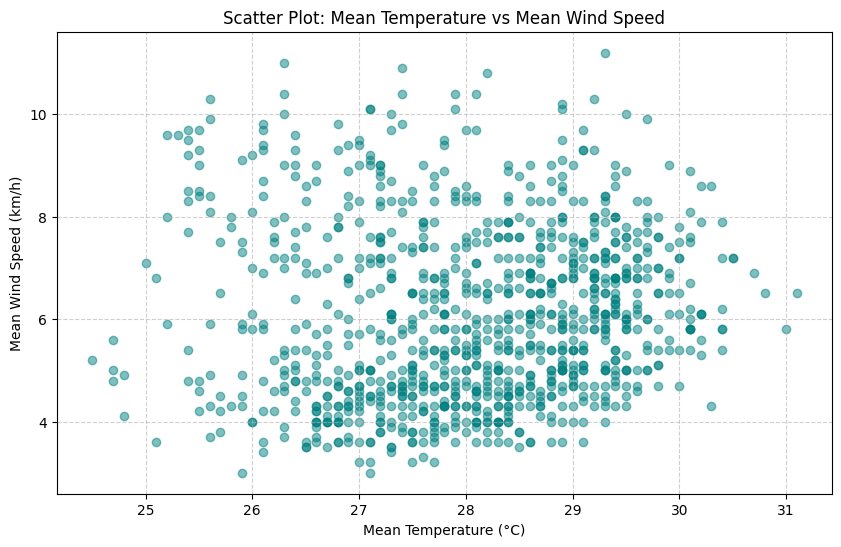

In [52]:
import matplotlib.pyplot as plt

# Create a scatter plot for Mean Temperature vs Mean Wind Speed
plt.figure(figsize=(10, 6))
plt.scatter(df1['Mean Temperature (°C)'], df1['Mean Wind Speed (km/h)'], alpha=0.5, color='teal')
plt.title('Scatter Plot: Mean Temperature vs Mean Wind Speed')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Mean Wind Speed (km/h)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

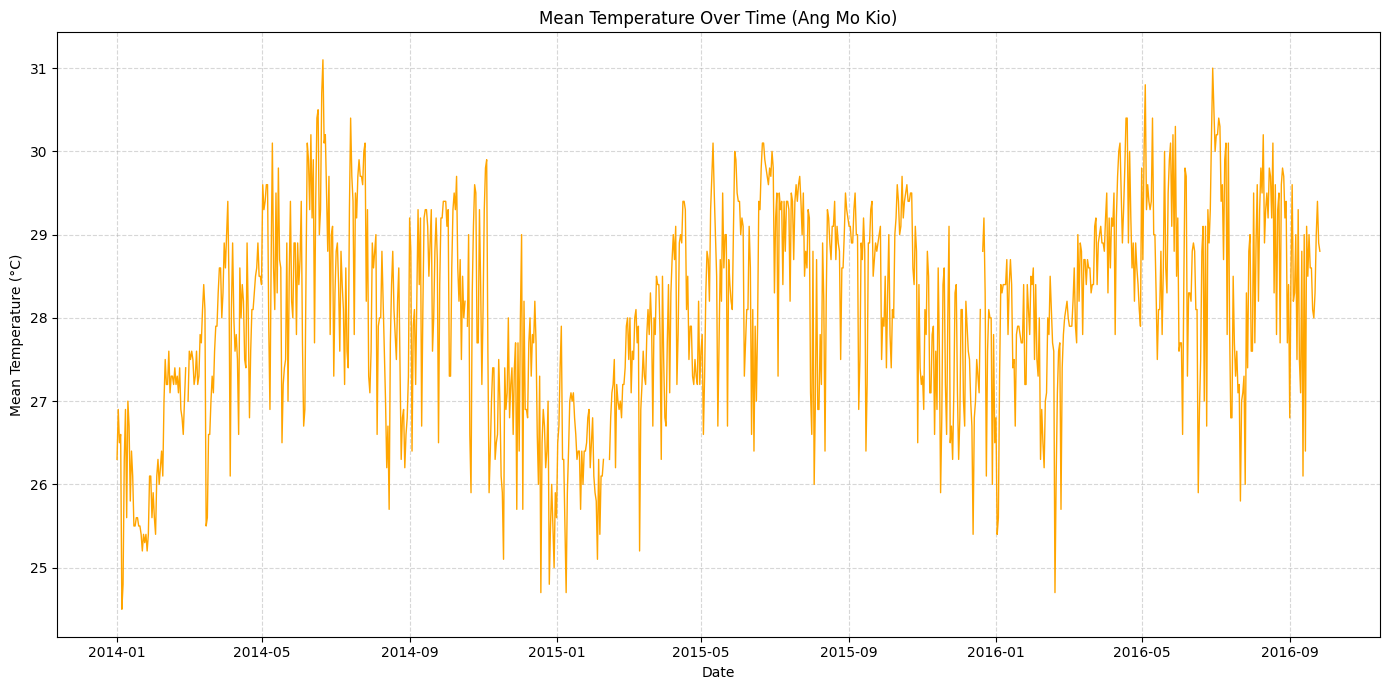

In [59]:
# Combine Year, Month, and Day into a single datetime column
df1['Date'] = pd.to_datetime(df1[['Year', 'Month', 'Day']])

# Plot Mean Temperature over time
plt.figure(figsize=(14, 7))
plt.plot(df1['Date'], df1['Mean Temperature (°C)'], color='orange', linewidth=1)
plt.title('Mean Temperature Over Time (Ang Mo Kio)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

DF2

In [54]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# changi.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
df2 = pd.read_csv('/content/sample_data/weather-forecast-data/changi.csv', delimiter=',', nrows = nRowsRead)
df2.dataframeName = 'changi.csv'
nRow, nCol = df2.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 14 columns


In [55]:
df2.head(5)

,Unnamed: 0,Station,Year,Month,Day,Daily Rainfall Total (mm),Highest 30 min Rainfall (mm),Highest 60 min Rainfall (mm),Highest 120 min Rainfall (mm),Mean Temperature (°C),Maximum Temperature (°C),Minimum Temperature (°C),Mean Wind Speed (km/h),Max Wind Speed (km/h)
0,0,Changi,2014,1,1,0.0,0.0,0.0,0.0,26.7,29.0,24.9,10.0,29.9
1,1,Changi,2014,1,2,0.0,0.0,0.0,0.0,27.4,30.9,25.0,11.9,36.0
2,2,Changi,2014,1,3,0.0,0.0,0.0,0.0,27.1,30.4,24.9,9.7,33.1
3,3,Changi,2014,1,4,0.0,0.0,0.0,0.0,27.1,31.1,24.9,6.4,25.9
4,4,Changi,2014,1,5,18.4,8.6,10.8,15.4,24.8,26.4,23.3,6.8,25.6


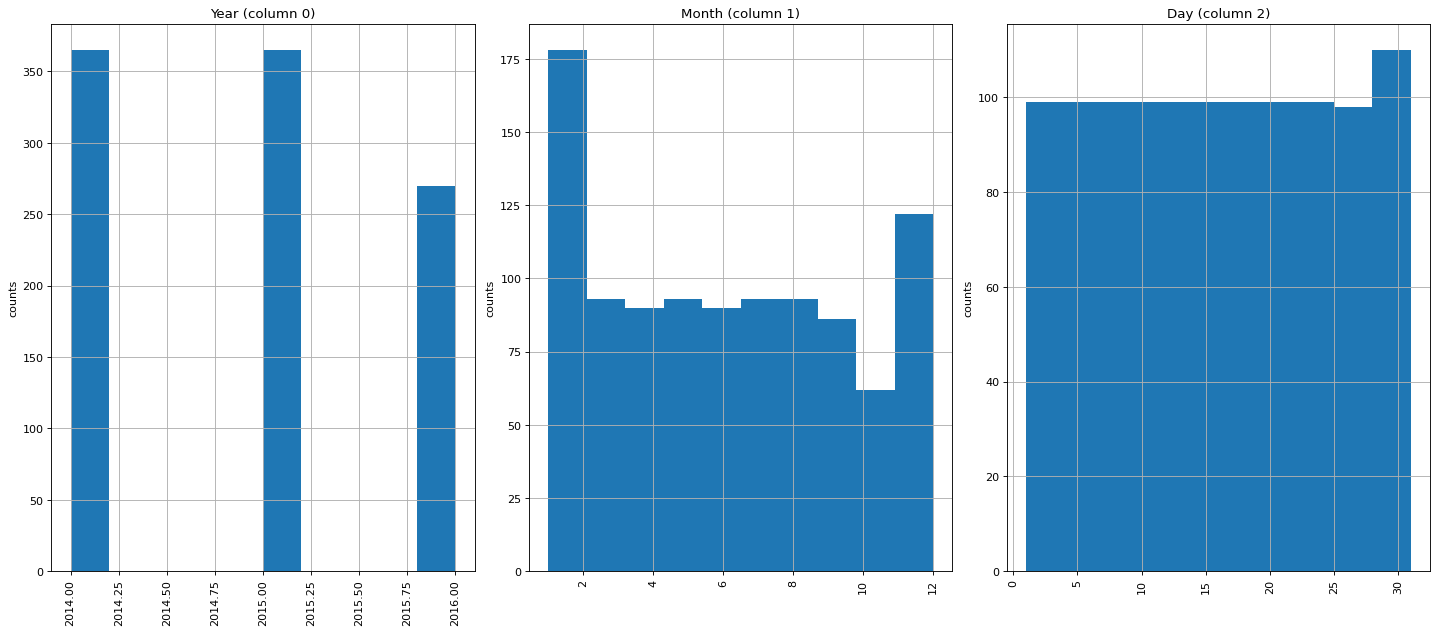

In [56]:
plotPerColumnDistribution(df2, 10, 5)

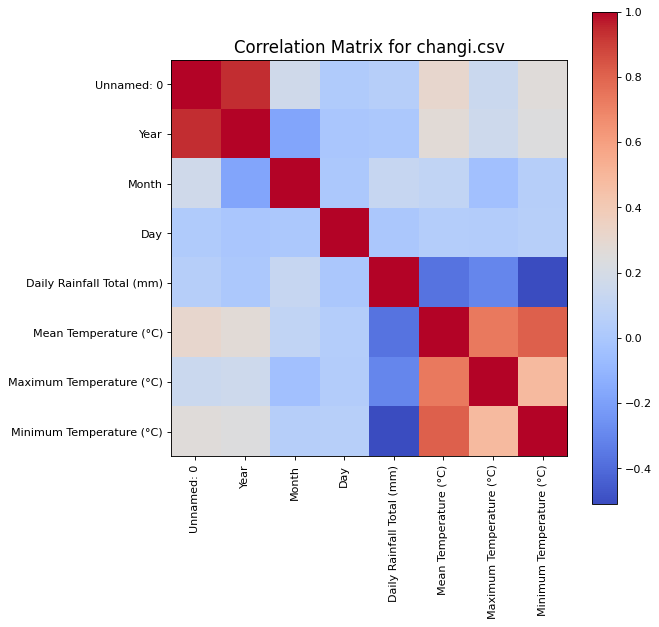

In [61]:
plotCorrelationMatrix(df2, 8)

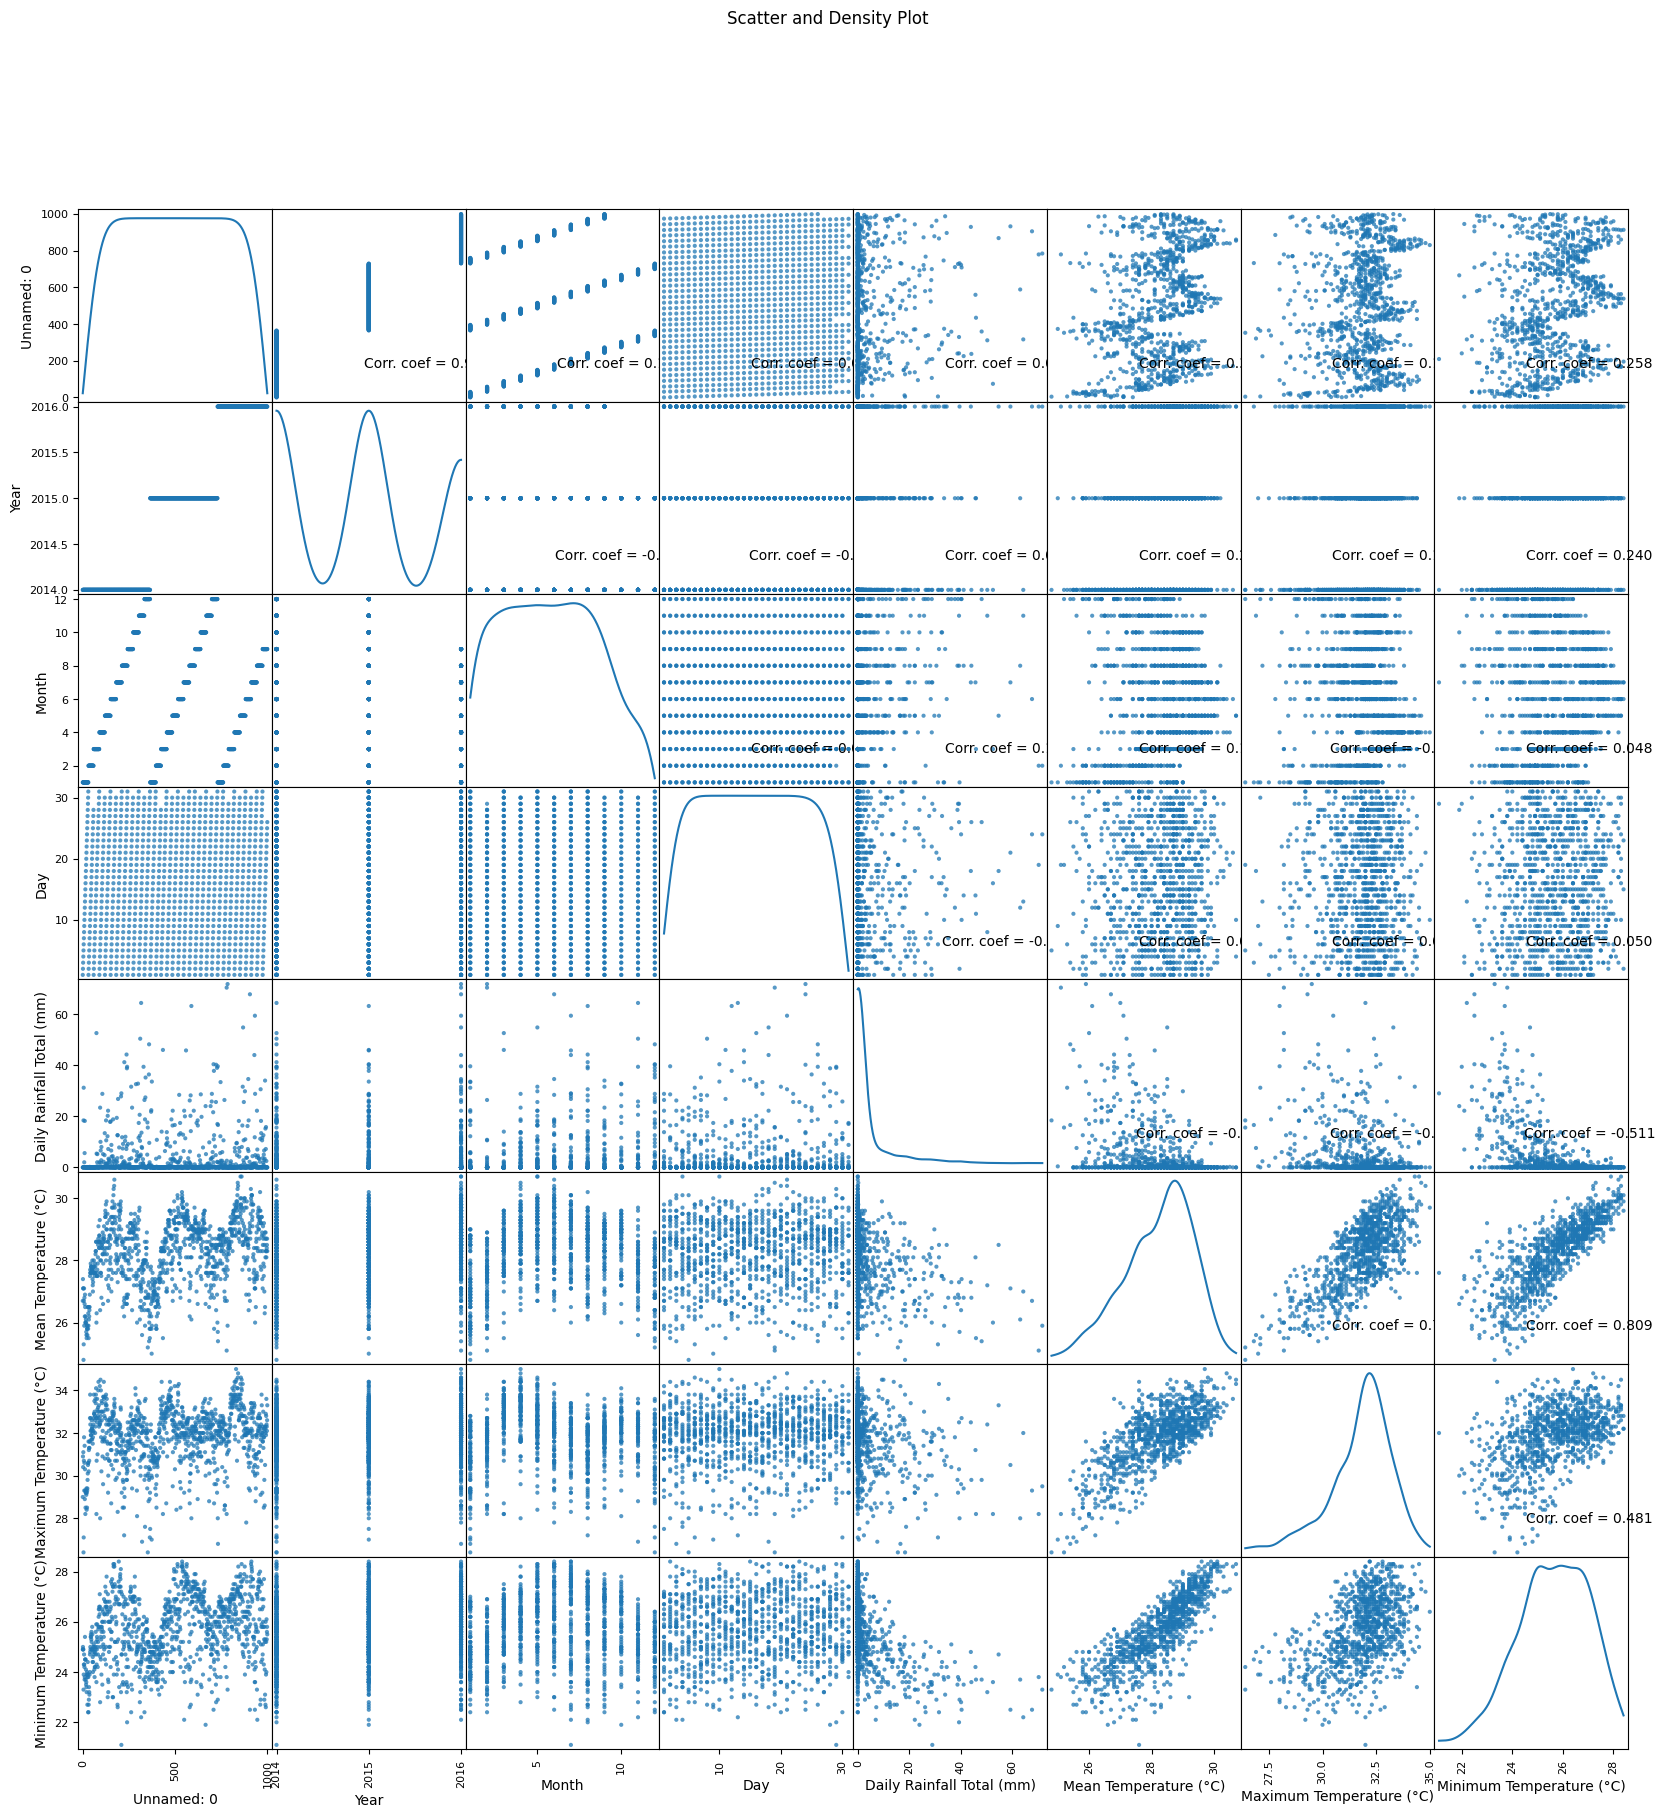

In [58]:
plotScatterMatrix(df2, 20, 10)

Model Performance for changi.csv:
Mean Absolute Error: 0.50 °C
R^2 Score: 0.58


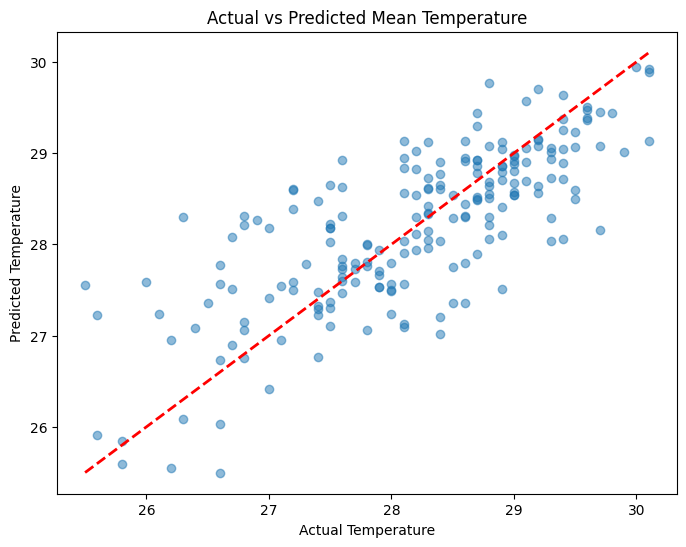

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare the data
# We'll use Year, Month, Day, and Rainfall to predict Mean Temperature
features = ['Year', 'Month', 'Day', 'Daily Rainfall Total (mm)']
target = 'Mean Temperature (°C)'

# Drop rows with missing values in our selected columns
ml_df = df2[features + [target]].dropna()

X = ml_df[features]
y = ml_df[target]

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make predictions and evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Model Performance for {df2.dataframeName}:')
print(f'Mean Absolute Error: {mae:.2f} °C')
print(f'R^2 Score: {r2:.2f}')

# 5. Visualize actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Mean Temperature')
plt.show()

Comparison for changi.csv:
--- Random Forest ---
MAE: 0.4969, R2: 0.5769
--- Linear Regression ---
MAE: 0.7378, R2: 0.1623


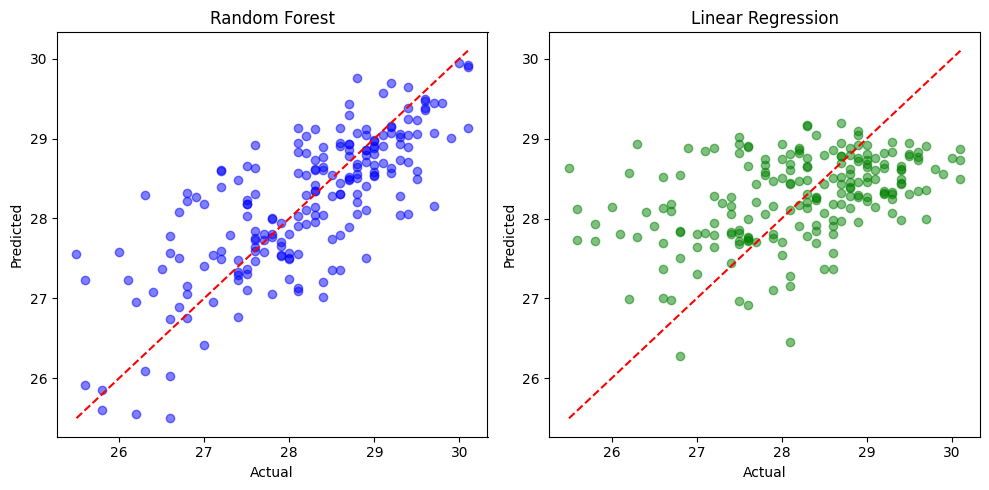

In [63]:
from sklearn.linear_model import LinearRegression

# 1. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Make predictions and evaluate
lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print(f'Comparison for {df2.dataframeName}:')
print(f'--- Random Forest ---')
print(f'MAE: {mae:.4f}, R2: {r2:.4f}')
print(f'--- Linear Regression ---')
print(f'MAE: {lr_mae:.4f}, R2: {lr_r2:.4f}')

# 3. Visualize Comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, lr_predictions, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

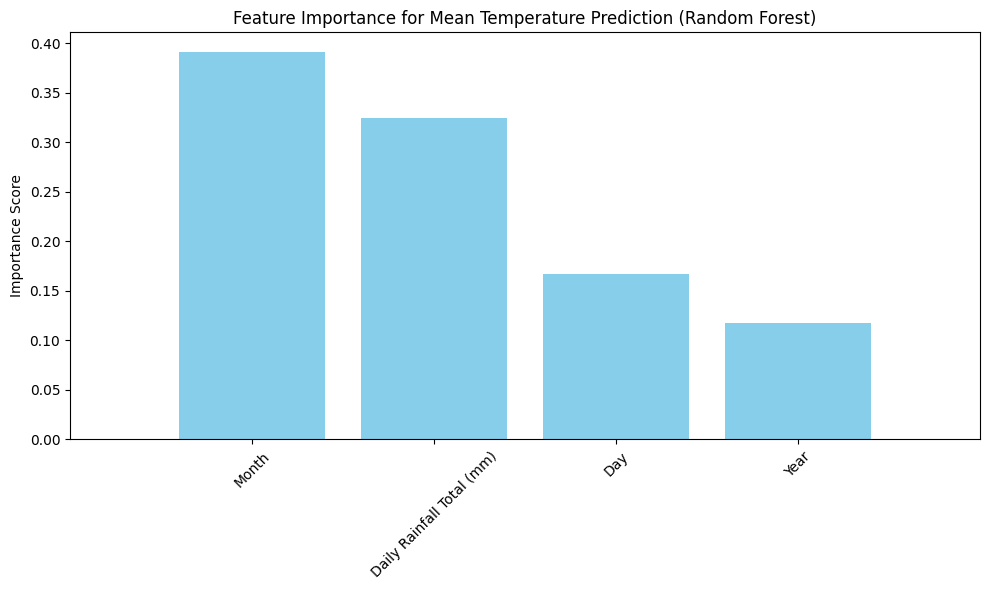

1. feature Month (0.3914)
2. feature Daily Rainfall Total (mm) (0.3242)
3. feature Day (0.1669)
4. feature Year (0.1175)


In [64]:
# Calculate feature importance from the Random Forest model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = [features[i] for i in indices]

# Create the plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Mean Temperature Prediction (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], color="skyblue", align="center")
plt.xticks(range(X.shape[1]), feature_names, rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Print the importance values
for f in range(X.shape[1]):
    print(f"{f + 1}. feature {feature_names[f]} ({importances[indices[f]]:.4f})")